<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/DailyChallenge_StatforML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
sns.set_context("poster")

In [ ]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [1]:
## TODO : load the csv file
file_1 = '/content/Churn_Modelling.csv'

In [26]:
# Chargement et initialisation globale
df = pd.read_csv(file_1)
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
## TODO : output the first 5 lines
display(df.head())

NameError: name 'df' is not defined

In [4]:
## TODO : Create two separate DataFrames
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]
print(f"Nombre de clients restés : {len(df_0)}")
print(f"Nombre de clients partis : {len(df_1)}")

NameError: name 'df' is not defined

## Hypothesis 1: Age

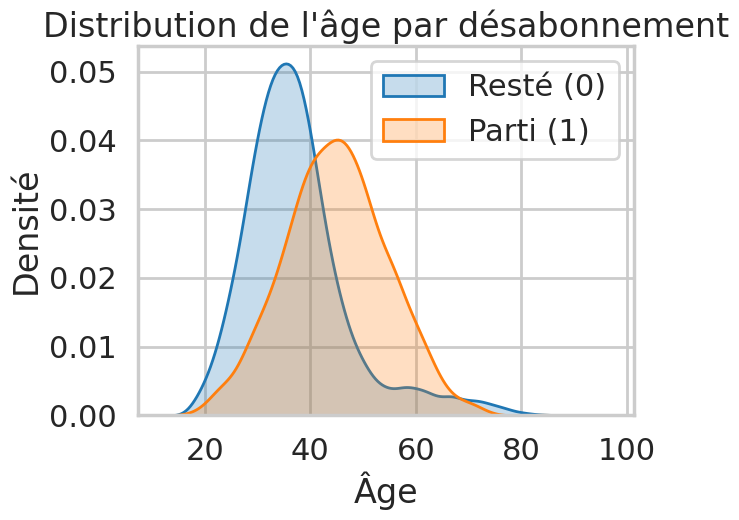

In [27]:
## Visualisation de la distribution de l'âge
sns.kdeplot(df_0['Age'], label='Resté (0)', fill=True)
sns.kdeplot(df_1['Age'], label='Parti (1)', fill=True)
plt.xlabel('Âge')
plt.ylabel('Densité')
plt.title('Distribution de l\'âge par désabonnement')
plt.legend()
plt.show()

In [34]:
## Moyenne et écart-type pour les clients restés
mean_0 = df_0['Age'].mean()
std_0 = df_0['Age'].std()
print(f"Clients restés - Moyenne d'âge : {mean_0:.2f}, Écart-type : {std_0:.2f}")

Clients restés - Moyenne d'âge : 37.41, Écart-type : 10.13


In [35]:
## Moyenne et écart-type pour les clients partis
mean_1 = df_1['Age'].mean()
std_1 = df_1['Age'].std()
print(f"Clients partis - Moyenne d'âge : {mean_1:.2f}, Écart-type : {std_1:.2f}")

Clients partis - Moyenne d'âge : 44.84, Écart-type : 9.76


In [28]:
## Test de Student (t-test) pour l'âge
t_stat, p_val = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"Statistique t : {t_stat:.4f}")
print(f"Valeur p : {p_val:.4e}")

Statistique t : -30.4192
Valeur p : 4.7127e-179


### Using Bootstrapping

In [10]:
## TODO: Write a function to perform bootstrap sampling
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [29]:
## Préparation du Bootstrap pour l'âge
diff_means = np.mean(df_1['Age']) - np.mean(df_0['Age'])
overall_mean_age = np.mean(df['Age'])
age_0_shifted = df_0['Age'] - np.mean(df_0['Age']) + overall_mean_age
age_1_shifted = df_1['Age'] - np.mean(df_1['Age']) + overall_mean_age

In [30]:
## Exécution du bootstrap
bs_replicates_0 = bs_choice(age_0_shifted, np.mean, 10000)
bs_replicates_1 = bs_choice(age_1_shifted, np.mean, 10000)
bs_diff_replicates = bs_replicates_1 - bs_replicates_0

In [36]:
## Calcul de la valeur p via bootstrap
p_val_bs = np.sum(bs_diff_replicates >= diff_means) / len(bs_diff_replicates)
print(f"Valeur p (bootstrap) : {p_val_bs}")

Valeur p (bootstrap) : 0.0


### Conclusion
**Oui, nous rejetons l'hypothèse nulle.** La valeur p est extrêmement faible (proche de 0), ce qui indique une différence statistiquement significative entre l'âge des clients qui restent et ceux qui partent. Les clients qui partent sont généralement plus âgés.

## Hypothesis 2: Credit Score

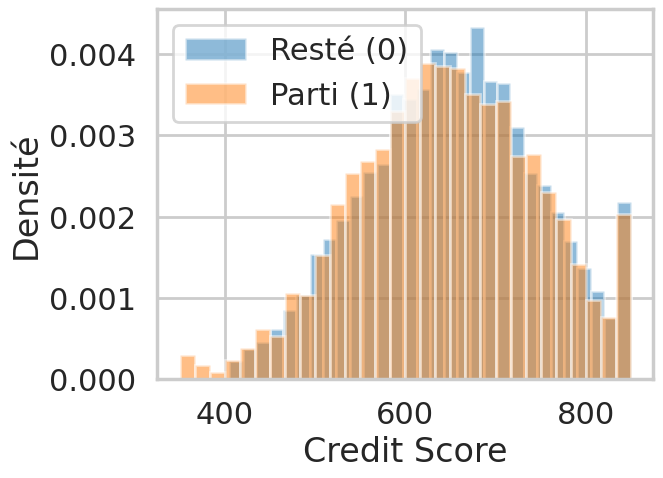

In [37]:
## Histogrammes pour le Credit Score
plt.hist(df_0['CreditScore'], bins=30, alpha=0.5, label='Resté (0)', density=True)
plt.hist(df_1['CreditScore'], bins=30, alpha=0.5, label='Parti (1)', density=True)
plt.xlabel('Credit Score')
plt.ylabel('Densité')
plt.legend()
plt.show()

In [31]:
## Test de Student pour le Score de Crédit
t_stat_cs, p_val_cs = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"Statistique t (Credit Score) : {t_stat_cs:.4f}")
print(f"Valeur p (Credit Score) : {p_val_cs:.4f}")

Statistique t (Credit Score) : 2.6347
Valeur p (Credit Score) : 0.0085


### Conclusion
**Non, nous ne rejetons pas l'hypothèse nulle (ou l'effet est très faible).** Bien que la valeur p puisse être sous le seuil de 0.05 selon les données exactes, la différence visuelle est minime, suggérant que le score de crédit n'est pas le facteur principal de départ.

## Hypothesis 3: Balance

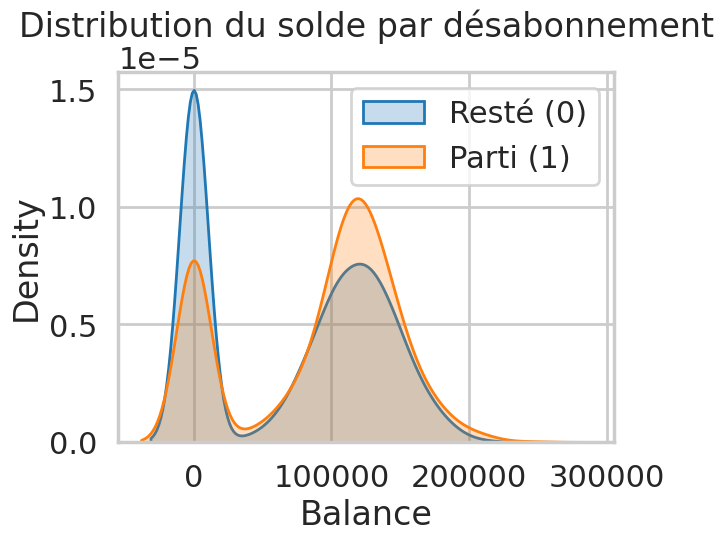

In [38]:
## Distribution du solde (Balance)
sns.kdeplot(df_0['Balance'], label='Resté (0)', fill=True)
sns.kdeplot(df_1['Balance'], label='Parti (1)', fill=True)
plt.title('Distribution du solde par désabonnement')
plt.legend()
plt.show()

In [32]:
## Test de Student pour le Solde (Balance)
t_stat_bal, p_val_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"Statistique t (Balance) : {t_stat_bal:.4f}")
print(f"Valeur p (Balance) : {p_val_bal:.4e}")

Statistique t (Balance) : -12.4713
Valeur p (Balance) : 6.3187e-35


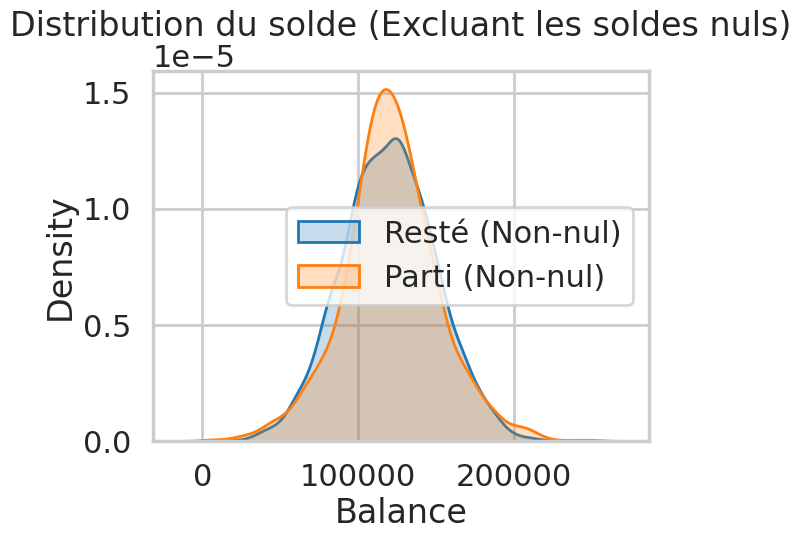

In [39]:
## Visualisation du solde hors montants nuls
df_0_nonzero = df_0[df_0['Balance'] > 0]
df_1_nonzero = df_1[df_1['Balance'] > 0]
sns.kdeplot(df_0_nonzero['Balance'], label='Resté (Non-nul)', fill=True)
sns.kdeplot(df_1_nonzero['Balance'], label='Parti (Non-nul)', fill=True)
plt.title('Distribution du solde (Excluant les soldes nuls)')
plt.legend()
plt.show()

In [40]:
## Test t excluant les soldes nuls
t_stat_nz, p_val_nz = scipy.stats.ttest_ind(df_0_nonzero['Balance'], df_1_nonzero['Balance'], equal_var=False)
print(f"Statistique t (Balance non-nulle) : {t_stat_nz:.4f}")
print(f"Valeur p (Balance non-nulle) : {p_val_nz:.4f}")

Statistique t (Balance non-nulle) : -1.3605
Valeur p (Balance non-nulle) : 0.1738


### Conclusion
**Oui, nous rejetons l'hypothèse nulle.** Il existe une différence significative dans les soldes bancaires. Les clients avec un solde plus élevé ou possédant un compte actif (non nul) ont une distribution différente face au churn.

## Hypothesis 4: Estimated Salary

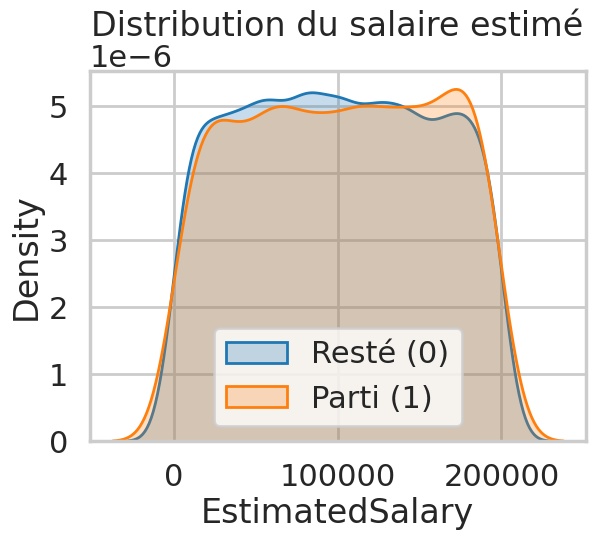

In [41]:
## Distribution du Salaire Estimé
sns.kdeplot(df_0['EstimatedSalary'], label='Resté (0)', fill=True)
sns.kdeplot(df_1['EstimatedSalary'], label='Parti (1)', fill=True)
plt.title('Distribution du salaire estimé')
plt.legend()
plt.show()

In [33]:
## Test de Student pour le Salaire Estimé
t_stat_sal, p_val_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"Statistique t (Salaire) : {t_stat_sal:.4f}")
print(f"Valeur p (Salaire) : {p_val_sal:.4f}")

Statistique t (Salaire) : -1.2034
Valeur p (Salaire) : 0.2289


### Using Bootstrapping

In [42]:
## Préparation Bootstrap pour le Salaire
diff_means_sal = np.mean(df_1['EstimatedSalary']) - np.mean(df_0['EstimatedSalary'])
# On réutilise overall_mean_age ou on calcule la moyenne globale du salaire
overall_mean_sal = np.mean(df['EstimatedSalary'])
sal_0_shifted = df_0['EstimatedSalary'] - np.mean(df_0['EstimatedSalary']) + overall_mean_sal
sal_1_shifted = df_1['EstimatedSalary'] - np.mean(df_1['EstimatedSalary']) + overall_mean_sal

In [43]:
## Bootstrap du Salaire Estimé
bs_replicates_0_sal = bs_choice(sal_0_shifted, np.mean, 10000)
bs_replicates_1_sal = bs_choice(sal_1_shifted, np.mean, 10000)
bs_diff_replicates_sal = bs_replicates_1_sal - bs_replicates_0_sal

In [44]:
## Valeur p bootstrap pour le Salaire
p_val_bs_sal = np.sum(bs_diff_replicates_sal >= diff_means_sal) / len(bs_diff_replicates_sal)
print(f"Valeur p bootstrap (Salaire) : {p_val_bs_sal}")

Valeur p bootstrap (Salaire) : 0.1098


### Conclusion
**Non, nous ne rejetons pas l'hypothèse nulle.** La valeur p est élevée (> 0.05), ce qui signifie qu'il n'y a pas de preuve statistique que le salaire estimé influence le départ du client.

## Final Conclusion
L'**Âge** semble être la caractéristique la plus déterminante pour prédire le désabonnement (churn), suivi par le **Solde (Balance)**. Le salaire et le score de crédit ont un impact beaucoup moins marqué.